# Portfolio Part 3 - Analysis of Mobile Price Data (2024 S1)

In this Portfolio task, you will work on a new dataset named 'Mobile Price Data', it contains numerous details about mobile phone hardware, specifications, and prices. Your main task is to train classification models to predict **mobile phone prices** ('price range' in the dataset)and evaluate the strengths and weaknesses of these models.

Here's the explanation of each column:

|Column|Meaning|
|:-----:|:-----:|
|battery power|Total energy a battery can store in one time measured in mAh|
|blue|Has bluetooth or not|
|clock speed|speed at which microprocessor executes instructions|
|dual sim|Has dual sim support or not|
|fc|Front Camera mega pixels|
|four g|Has 4G or not|
|int memory|Internal Memory in Gigabytes|
|m dep|Mobile Depth in cm|
|mobile wt|Weight of mobile phone|
|n cores|Number of cores of processor|
|pc|Primary Camera mega pixels|
|px height|Pixel Resolution Height|
|px width|Pixel Resolution Width|
|ram|Random Access Memory in Mega Bytes|
|sc h|Screen Height of mobile in cm|
|sc w|Screen Width of mobile in cm|
|talk time|longest time that a single battery charge will last when you are|
|three g|Has 3G or not|
|touch screen|Has touch screen or not|
|wifi|Has wifi or not|
|price range|This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost)|

Blue, dual sim, four g, three g, touch screen, and wifi are all binary attributes, 0 for not and 1 for yes.

Your high level goal in this notebook is to build and evaluate predictive models for 'price range' from other available features. More specifically, you need to **complete the following major steps**:

1. ***Explore the data*** and ***clean the data if necessary***. For example, remove abnormal instanaces and replace missing values.

2. ***Study the correlation*** between 'price range' with other features. And ***select the variables*** that you think are helpful for predicting the price range. We do not limit the number of variables.

3. ***Split the dataset*** (Trainging set : Test set = 8 : 2)

4. ***Train a logistic regression model*** to predict 'price range' based on the selected features (from the second step). ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.) ***Explain your model and evaluate its performance*** (Is the model performing well? If yes, what factors might be contributing to the good performance of your model? If not, how can improvements be made?).

5. ***Train a KNN model*** to predict 'price range' based on the selected features (you can use the features selected from the second step and set K with an ad-hoc manner in this step. ***Calculate the accuracy*** of your model. (You are required to report the accuracy from both training set and test set.)

6. ***Tune the hyper-parameter K*** in KNN (Hints: GridsearchCV), ***visualize the results***, and ***explain*** how K influences the prediction performance.

  Hints for visualization: You can use line chart to visualize K and mean accuracy scores on test set.

Note 1: In this assignment, we no longer provide specific guidance and templates for each sub task. You should learn how to properly comment your notebook by yourself to make your notebook file readable.

Note 2: You will not being evaluated on the accuracy of the model but on the process that you use to generate it and your explanation.

In [2]:
#Library importation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

In [3]:
df=pd.read_csv('Mobile_Price_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     1999 non-null   float64
 7   m_dep          1999 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       1999 non-null   float64
 13  ram            1999 non-null   float64
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        1999 non-null   float64
 18  touch_sc

In [59]:
#Question 1

#Identify and remove null values
nullcount = df.isna().sum()
nullcount

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       1
m_dep            1
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         1
ram              1
sc_h             0
sc_w             0
talk_time        0
three_g          1
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [60]:
#Fill in the missing values with the mean value. (Only fill in the values that are not true or false.)
int_memory_mean = df['int_memory'].mean()
df['int_memory'] = df['int_memory'].fillna(int_memory_mean)

m_dep_mean = df['m_dep'].mean()
df['m_dep'] = df['m_dep'].fillna(m_dep_mean)

px_width_mean = df['px_width'].mean()
df['px_width'] = df['px_width'].fillna(px_width_mean)

ram_mean = df['ram'].mean()
df['ram'] = df['ram'].fillna(ram_mean)



In [61]:
#Remove missing values
df = df.dropna()

In [84]:
#Quesition 2 - Correlation between price range and selected variables
df.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011501,0.011368,-0.042104,0.033531,0.015431,-0.004480,0.034824,0.002114,-0.029567,...,0.014698,-0.008230,-0.000504,-0.030247,-0.021551,0.052469,0.011385,-0.010269,-0.008591,0.200856
blue,0.011501,1.000000,0.021654,0.035701,0.003217,0.013924,0.041401,0.004218,-0.009145,0.035844,...,-0.006464,-0.041621,0.026053,-0.002402,0.000867,0.014027,-0.029969,0.009567,-0.021385,0.020357
clock_speed,0.011368,0.021654,1.000000,-0.001543,-0.000257,-0.043307,0.006383,-0.013941,0.012604,-0.005571,...,-0.014718,-0.009644,0.003595,-0.029346,-0.007498,-0.011475,-0.046569,0.019995,-0.024707,-0.006503
dual_sim,-0.042104,0.035701,-0.001543,1.000000,-0.028760,0.002718,-0.014612,-0.022320,-0.008453,-0.024340,...,-0.021291,0.014370,0.041401,-0.012503,-0.016923,-0.039503,-0.014287,-0.016632,0.022267,0.017669
fc,0.033531,0.003217,-0.000257,-0.028760,1.000000,-0.016200,-0.031052,-0.002976,0.023216,-0.013613,...,-0.009677,-0.005263,0.014858,-0.010594,-0.012180,-0.006761,0.002006,-0.015218,0.020469,0.021832
four_g,0.015431,0.013924,-0.043307,0.002718,-0.016200,1.000000,0.008514,-0.000949,-0.016027,-0.029397,...,-0.019641,0.007287,0.007613,0.026646,0.036770,-0.046726,0.584157,0.017248,-0.018101,0.014990
int_memory,-0.004480,0.041401,0.006383,-0.014612,-0.031052,0.008514,1.000000,0.006388,-0.035220,-0.027927,...,0.010662,-0.008505,0.032551,0.038044,0.012513,-0.002015,-0.009479,-0.028097,0.006811,0.043983
m_dep,0.034824,0.004218,-0.013941,-0.022320,-0.002976,-0.000949,0.006388,1.000000,0.022260,-0.004299,...,0.024787,0.023006,-0.009989,-0.025553,-0.019315,0.017832,-0.012165,-0.003506,-0.027500,0.000002
mobile_wt,0.002114,-0.009145,0.012604,-0.008453,0.023216,-0.016027,-0.035220,0.022260,1.000000,-0.019356,...,0.001388,0.000291,-0.002920,-0.033272,-0.020491,0.006308,0.001854,-0.014920,0.000124,-0.030554
n_cores,-0.029567,0.035844,-0.005571,-0.024340,-0.013613,-0.029397,-0.027927,-0.004299,-0.019356,1.000000,...,-0.006598,0.024483,0.004658,0.000056,0.026002,0.013210,-0.014549,0.023448,-0.009639,0.004251


In [62]:
#Display correlation of selected variables
correl = df[['price_range', 'ram', 'px_height', 'px_width', 'battery_power']].corr()
print(correl)

               price_range       ram  px_height  px_width  battery_power
price_range       1.000000  0.917039   0.149076  0.165688       0.200856
ram               0.917039  1.000000  -0.020098  0.003970      -0.000504
px_height         0.149076 -0.020098   1.000000  0.510691       0.014698
px_width          0.165688  0.003970   0.510691  1.000000      -0.008230
battery_power     0.200856 -0.000504   0.014698 -0.008230       1.000000


C:\Users\abhay\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


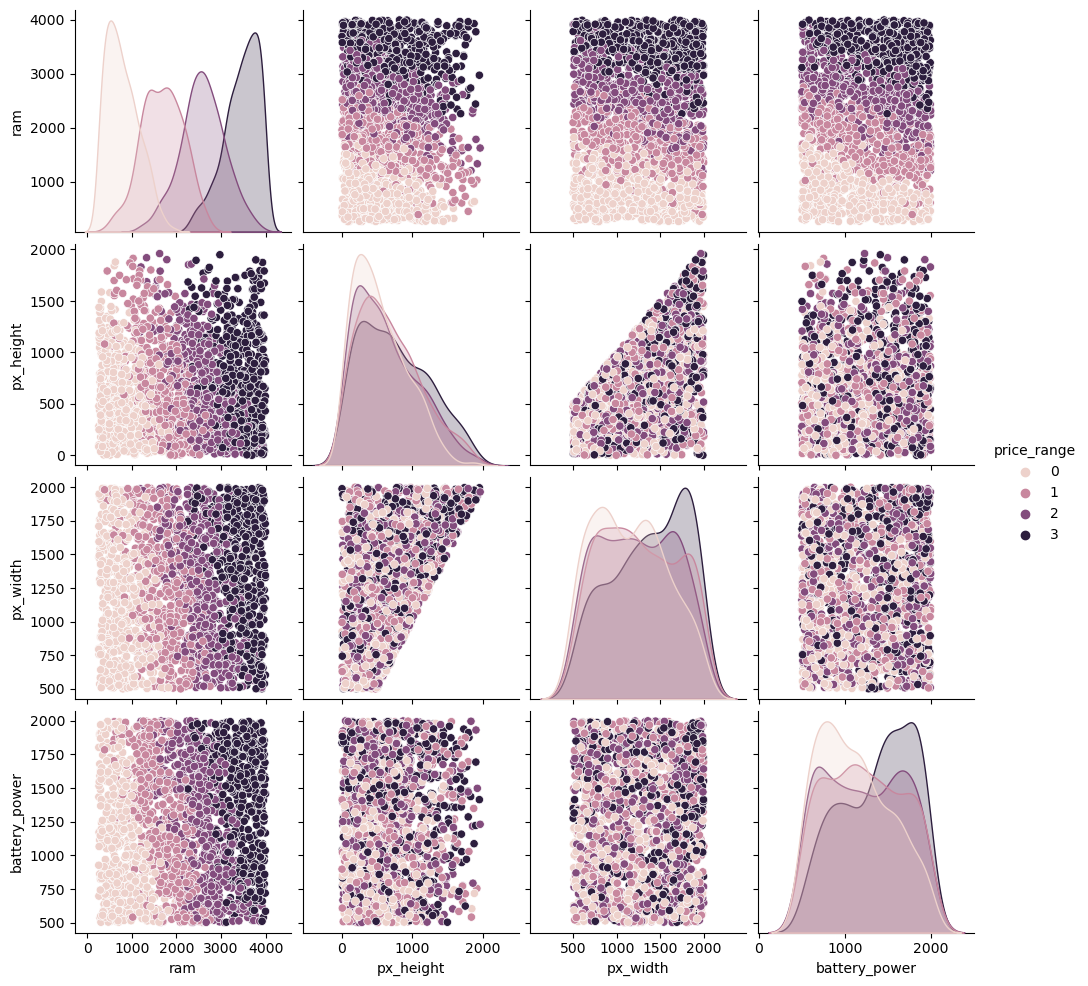

In [82]:
#Display the correlarions
s = sns.pairplot(df[['price_range', 'ram', 'px_height', 'px_width', 'battery_power']], hue='price_range')

In [64]:
#Question 3

#training data containing 80% of the data
train_1, test_1 = train_test_split(df, test_size=0.2, random_state=142)
print(train_1.shape)
print(test_1.shape)

(1599, 21)
(400, 21)


In [65]:
#Question 4 - Linear Regression Models

reg_1 = linear_model.LinearRegression()
X_train_1= train_1[['ram', 'battery_power']]
y_train_1 = train_1['price_range']

X_test_1= test_1[['ram', 'battery_power']]
y_test_1 = test_1['price_range']

reg_1.fit(X_train_1, y_train_1)

LinearRegression()

In [66]:
predicted_1 = reg_1.predict(X_test_1)
mse_1 = ((np.array(y_test_1)-predicted_1)**2).sum()/len(y_test_1)
r2_1 = r2_score(y_test_1, predicted_1)
print("MSE:", mse_1)
print("R Squared:", r2_1)

MSE: 0.14975570543160976
R Squared: 0.8841118748443475


In [ ]:
#The MSE value of 0.1497557 reflects that the model is performing satisfactorily. This could be due to 'price_range' having 
#one of the strongest correlations with 'ram' and 'battery_power'. The r^2 value of 0.884 shows that the model predicts 88.4%
#of the relationship, due to the strong correlations between 'price_range', 'ram' and 'battery_power'.

In [67]:
reg_2 = linear_model.LinearRegression()
X_train_2= train_1[['px_width', 'px_height','ram']]
y_train_2 = train_1['price_range']

X_test_2= test_1[['px_width', 'px_height','ram']]
y_test_2 = test_1['price_range']

reg_2.fit(X_train_2, y_train_2)

LinearRegression()

In [68]:
predicted_2 = reg_2.predict(X_test_2)
mse_2 = ((np.array(y_test_2)-predicted_2)**2).sum()/len(y_test_2)
r2_2 = r2_score(y_test_2, predicted_2)
print("MSE:", mse_2)
print("R Squared:", r2_2)

MSE: 0.13989930775933296
R Squared: 0.8917392266286195


In [ ]:
#The MSE in this linear regression model shows that the model predicts at an adequate level. However, if the model wanted to 
#perform better, more models could be created with different features that display a higher correlation. The r^2 value of 
#0.89 shows that the model predicts 89% of the relationship which is good. 

In [69]:
#Question 5 - Training the KNN Model and calculate the accuracy

X = df[['ram', 'battery_power', 'px_width', 'px_height']]
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142)

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

y_train_prediction = knn.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_prediction)

y_test_prediction = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_prediction)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)



Training Accuracy: 0.9543464665415885
Test Accuracy: 0.9275


In [71]:
#Question 6 - Tuning the hyper-parameter K
para = {'n_neighbors': range(1, 31)}
grid_search = GridSearchCV(KNeighborsClassifier(), para, cv=5)
grid_search.fit(X_train, y_train)



GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)})

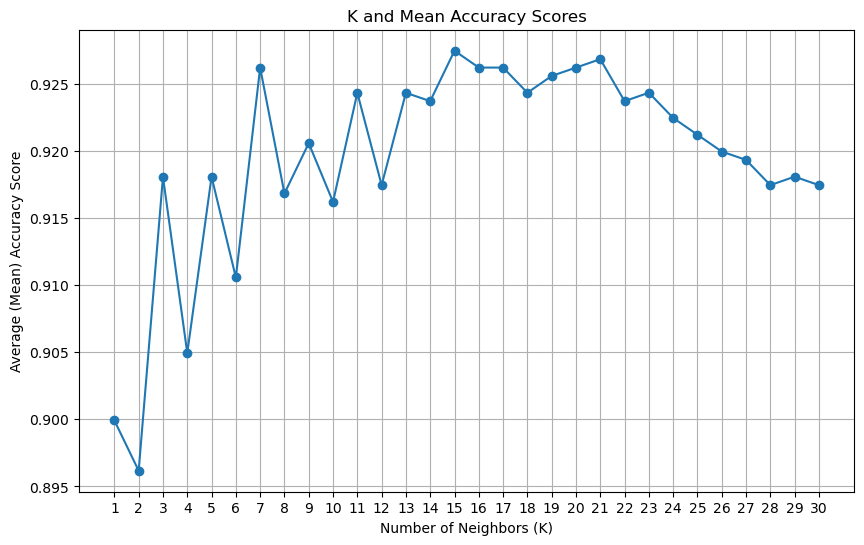

In [83]:
#Visualise the results
test_scores = grid_search.cv_results_['mean_test_score']
k_values = range(1, 31)
plt.figure(figsize=(10,6))
plt.plot(k_values, test_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Average (Mean) Accuracy Score')
plt.title('K and Mean Accuracy Scores')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
#EXPLANATION
#If the value of k is too small, it will have a higher influence on the prediction. The larger value of the prediction will 
#make it computationally expensive. However, if the k value of bigger, it may include features form other categories which 
#could potentially lead to errors, particularly if the categories are similar or of they overlap 